# Experiment 03 — Threshold Trade-offs

## Objective
Understand how changing the classification threshold affects precision, recall, and business cost in an imbalanced dataset.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_recall_curve
)

## Problem

In imbalanced classification problems, accuracy can be misleading.

Even with the same model, changing the decision threshold can significantly alter:
- the number of false positives
- the number of false negatives
- overall system behaviour

## Key Question

What kind of error can the system afford?

## Dataset

We generate a synthetic dataset with:
- 95% negative class
- 5% positive class

This simulates real-world scenarios such as fraud detection.

In [2]:
X, y = make_classification(
    n_samples=5000,
    n_features=10,
    n_informative=4,
    n_redundant=2,
    weights=[0.95, 0.05],  # 5% positives
    flip_y=0.01,
    random_state=42
)

print(pd.Series(y).value_counts(normalize=True))

0    0.9458
1    0.0542
Name: proportion, dtype: float64


## Model

We use Logistic Regression as a simple baseline model.

The model outputs probabilities, not final decisions.
These probabilities will later be converted into predictions using different thresholds.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [4]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_probs = model.predict_proba(X_test)[:, 1]

## Decision Threshold

The model outputs probabilities between 0 and 1.

A threshold is used to convert these probabilities into class predictions:

- If probability ≥ threshold → predict 1
- Otherwise → predict 0

Changing the threshold changes system behaviour without changing the model.

In [5]:
def evaluate_threshold(y_true, y_probs, threshold):
    y_pred = (y_probs >= threshold).astype(int)

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    cm = confusion_matrix(y_true, y_pred)

    tn, fp, fn, tp = cm.ravel()

    return {
        "threshold": threshold,
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "false_positives": fp,
        "false_negatives": fn,
        "true_positives": tp,
        "true_negatives": tn
    }

## Experiment Setup

We evaluate the model at three thresholds:

- 0.50 (default)
- 0.30 (moderate)
- 0.10 (aggressive)

For each threshold, we measure:
- Precision
- Recall
- F1 Score
- False Positives
- False Negatives

In [ ]:
thresholds = [0.50, 0.30, 0.10]

results = [evaluate_threshold(y_test, y_probs, t) for t in thresholds]
results_df = pd.DataFrame(results)
results_df = results_df.round(3)
results_df

,threshold,accuracy,precision,recall,f1,false_positives,false_negatives,true_positives,true_negatives
0,0.5,0.946,0.000000,0.000000,0.000000,0,54,0,946
1,0.3,0.938,0.214286,0.055556,0.088235,11,51,3,935
2,0.1,0.864,0.184615,0.444444,0.260870,106,30,24,840


## Critical Observation

At the default threshold of 0.50, the model predicts no positive cases.

This results in:
- zero recall
- complete failure to detect the minority class

This demonstrates that a standard threshold may be inappropriate in imbalanced settings.

## Key Insight

The model itself is not the problem.

The decision threshold is too conservative for this problem.

Lowering the threshold allows the system to capture more positive cases, 
at the cost of increased false positives.

## Threshold Comparison

We now evaluate the same model at multiple thresholds to see how decision policy changes system behaviour.

## Results

The table above shows how performance metrics and error types change across thresholds.

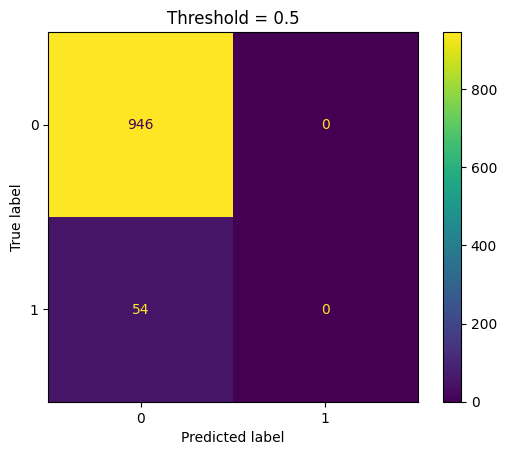

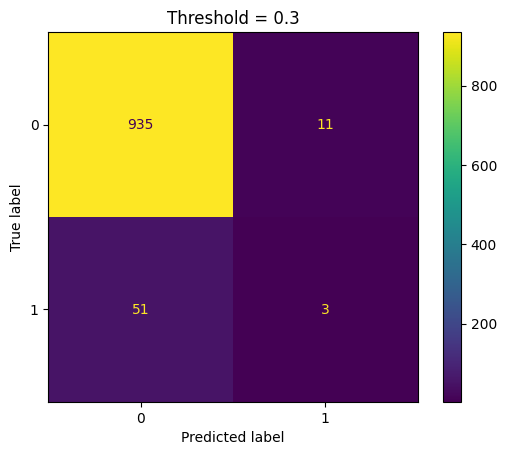

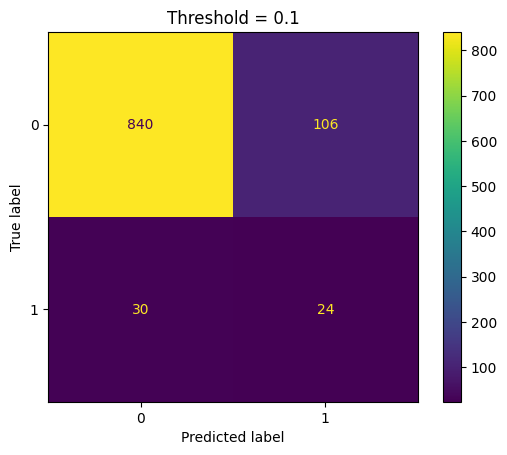

In [7]:
for t in thresholds:
    y_pred = (y_probs >= t).astype(int)
    cm = confusion_matrix(y_test, y_pred)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(f"Threshold = {t}")
    plt.show()

## Observations

- Lower thresholds increase recall but reduce precision
- Higher thresholds reduce false positives but increase false negatives
- The model behaviour changes significantly even though the model itself is unchanged

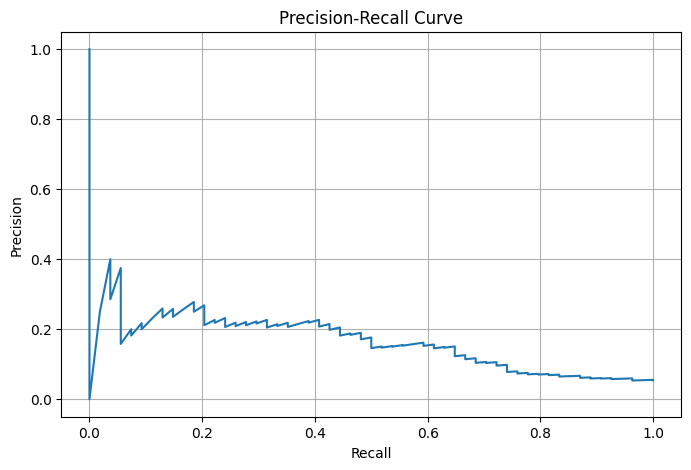

In [8]:
precisions, recalls, pr_thresholds = precision_recall_curve(y_test, y_probs)

plt.figure(figsize=(8, 5))
plt.plot(recalls, precisions)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.grid(True)
plt.show()

In [ ]:
FP_COST = 1
FN_COST = 10

results_df["business_cost"] = (
    results_df["false_positives"] * FP_COST +
    results_df["false_negatives"] * FN_COST
)

results_df.sort_values("business_cost").reset_index(drop=True)

,threshold,accuracy,precision,recall,f1,false_positives,false_negatives,true_positives,true_negatives,business_cost
2,0.1,0.864,0.184615,0.444444,0.260870,106,30,24,840,406
1,0.3,0.938,0.214286,0.055556,0.088235,11,51,3,935,521
0,0.5,0.946,0.000000,0.000000,0.000000,0,54,0,946,540


In [ ]:
from pathlib import Path
Path("outputs").mkdir(exist_ok=True)
results_df.to_csv("outputs/threshold_results.csv", index=False)

In [ ]:
plt.figure(figsize=(8,5))
plt.hist(y_probs, bins=30)
plt.xlabel("Predicted probability")
plt.ylabel("Count")
plt.title("Distribution of Predicted Probabilities")
plt.grid(True)
plt.show()

## System Design Implication

Threshold selection is not just a technical parameter.

It defines how the system behaves in production and should be aligned 
with the cost of different types of errors.

The same model can behave conservatively or aggressively depending on the threshold chosen.

## Business Interpretation

When false negatives are significantly more expensive than false positives, 
lower thresholds can reduce total system cost, even if precision decreases.

This highlights the importance of aligning model decisions with real-world impact.

## Key Takeaway

The model does not make decisions — the threshold does.

Threshold selection is a product and risk decision, not just a technical one.